# Warm-up

In [ ]:
# example of converting between probability and odds
# define our probability of success
prob = 0.8
print('Probability %.1f' % prob)
# convert probability to odds
odds = prob / (1 - prob)
print('Odds %.1f' % odds)
# convert back to probability
prob = odds / (odds + 1)
print('Probability %.1f' % prob) 

Probability 0.8
Odds 4.0
Probability 0.8


In [ ]:
# example of converting between probability and log-odds
from math import log
from math import exp
# define our probability of success
prob = 0.8
print('Probability %.1f' % prob)
# convert probability to odds
odds = prob / (1 - prob)
print('Odds %.1f' % odds)
# convert odds to log-odds
logodds = log(odds)
print('Log-Odds %.1f' % logodds)
# convert log-odds to a probability
prob = 1 / (1 + exp(-logodds))
print('Probability %.1f' % prob)

Probability 0.8
Odds 4.0
Log-Odds 1.4
Probability 0.8


In [ ]:
# test of Bernoulli likelihood function

# likelihood function for Bernoulli distribution
def likelihood(y, yhat):
	return yhat * y + (1 - yhat) * (1 - y)

# test for y=1
y, yhat = 1, 0.9
print('y=%.1f, yhat=%.1f, likelihood: %.3f' % (y, yhat, likelihood(y, yhat)))
y, yhat = 1, 0.1
print('y=%.1f, yhat=%.1f, likelihood: %.3f' % (y, yhat, likelihood(y, yhat)))
# test for y=0
y, yhat = 0, 0.1
print('y=%.1f, yhat=%.1f, likelihood: %.3f' % (y, yhat, likelihood(y, yhat)))
y, yhat = 0, 0.9
print('y=%.1f, yhat=%.1f, likelihood: %.3f' % (y, yhat, likelihood(y, yhat)))

y=1.0, yhat=0.9, likelihood: 0.900
y=1.0, yhat=0.1, likelihood: 0.100
y=0.0, yhat=0.1, likelihood: 0.900
y=0.0, yhat=0.9, likelihood: 0.100


# Logistic Regression

n →number of features

m →number of training examples

X →input data matrix of shape (m x n)

y →true/ target value (can be 0 or 1 only)

x(i), y(i)→ith training example

w → weights (parameters) of shape (n x 1)

b →bias (parameter), a real number that can be broadcasted.

y_hat(y with a cap/hat)→ hypothesis (outputs values between 0 and 1)

In [18]:
import numpy as np
def sigmoid(z):
    return 1.0/(1 + np.exp(-z))

print(sigmoid(0.5))

0.6224593312018546


In [17]:
import numpy as np
def loss(y, y_hat):
    loss = -np.mean(y*(np.log(y_hat)) - (1-y)*np.log(1-y_hat))
    return loss

print(loss())

In [ ]:
def accuracy(y, y_hat):
    accuracy = np.sum(y == y_hat) / len(y)
    return accuracy

In [ ]:
def gradients(X, y, y_hat):
    
    # X --> Input.
    # y --> true/target value.
    # y_hat --> hypothesis/predictions.
    # w --> weights (parameter).
    # b --> bias (parameter).
    
    # m-> number of training examples.
    m = X.shape[0]
    
    # Gradient of loss w.r.t weights.
    dw = (1/m)*np.dot(X.T, (y_hat - y))
    
    # Gradient of loss w.r.t bias.
    db = (1/m)*np.sum((y_hat - y)) 
    
    return dw, db

In [ ]:
def plot_decision_boundary(X, w, b):
    
    # X --> Inputs
    # w --> weights
    # b --> bias
    
    # The Line is y=mx+c
    # So, Equate mx+c = w.X + b
    # Solving we find m and c
    x1 = [min(X[:,0]), max(X[:,0])]
    m = -w[0]/w[1]
    c = -b/w[1]
    x2 = m*x1 + c
    
    # Plotting
    fig = plt.figure(figsize=(10,8))
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "g^")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
    plt.xlim([-3, 3])
    plt.ylim([-1, 2.2])
    plt.xlabel("feature 1")
    plt.ylabel("feature 2")
    plt.title('Decision Boundary')
    plt.plot(x1, x2, 'y-')

In [ ]:
def normalize(X):
    
    # X --> Input.
    
    # m-> number of training examples
    # n-> number of features 
    m, n = X.shape
    
    # Normalizing all the n features of X.
    for i in range(n):
        X = (X - X.mean(axis=0))/X.std(axis=0)
        
    return X

In [ ]:
def predict(X):
    
    # X --> Input.
    
    # Normalizing the inputs.
    x = normalize(X)
    
    # Calculating presictions/y_hat.
    preds = sigmoid(np.dot(X, w) + b)
    
    # Empty List to store predictions.
    pred_class = []
    # if y_hat >= 0.5 --> round up to 1
    # if y_hat < 0.5 --> round up to 1
    pred_class = [1 if i > 0.5 else 0 for i in preds]
    
    return np.array(pred_class)

In [ ]:
def train(X, y, bs, epochs, lr):
    
    # X --> Input.
    # y --> true/target value.
    # bs --> Batch Size.
    # epochs --> Number of iterations.
    # lr --> Learning rate.
        
    # m-> number of training examples
    # n-> number of features 
    m, n = X.shape
    
    # Initializing weights and bias to zeros.
    w = np.zeros((n,1))
    b = 0
    
    # Reshaping y.
    y = y.reshape(m,1)
    
    # Normalizing the inputs.
    x = normalize(X)
    
    # Empty list to store losses.
    losses = []
    
    # Training loop.
    for epoch in range(epochs):
        for i in range((m-1)//bs + 1):
            
            # Defining batches. SGD.
            start_i = i*bs
            end_i = start_i + bs
            xb = X[start_i:end_i]
            yb = y[start_i:end_i]
            
            # Calculating hypothesis/prediction.
            y_hat = sigmoid(np.dot(xb, w) + b)
            
            # Getting the gradients of loss w.r.t parameters.
            dw, db = gradients(xb, yb, y_hat)
            
            # Updating the parameters.
            w -= lr*dw
            b -= lr*db
        
        # Calculating loss and appending it in the list.
        l = loss(y, sigmoid(np.dot(X, w) + b))
        losses.append(l)
        
    # returning weights, bias and losses(List).
    return w, b, losses

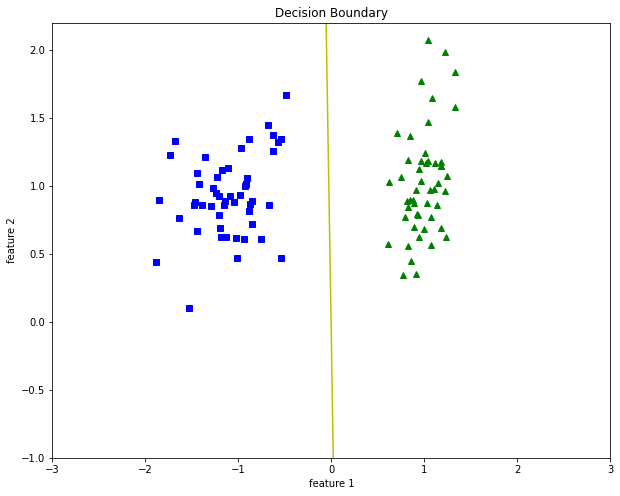

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt


X, y = make_classification(n_features=2, n_redundant=0, 
                           n_informative=2, random_state=1, 
                           n_clusters_per_class=1)
# Training 
w, b, l = train(X, y, bs=100, epochs=1000, lr=0.01)
# Plotting Decision Boundary
plot_decision_boundary(X, w, b)

In [ ]:
accuracy(y, predict(X))

1.0

In [11]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, noise=0.24)

# Training 
w, b, l = train(X, y, bs=100, epochs=1000, lr=0.01)
# Plotting Decision Boundary
plot_decision_boundary(X, w, b)
accuracy(y, predict(X))


NameError: ignored